# FIT DNU CONQUER - Phân tích Dữ liệu Chuỗi Thời gian (Time Series)

## Lab 3: Dự báo Ô nhiễm không khí với SARIMA (Seasonal ARIMA)

**Nhóm:** FIT DNU CONQUER

**Chủ đề 5.3.2:** SARIMA – thêm mùa vụ (seasonality)

**Nội dung thực hiện:**

1.  **Q1: Kiểm tra tính mùa vụ (Seasonality Check):**
    * Sử dụng biểu đồ tự tương quan (ACF) để chứng minh chuỗi dữ liệu có tính mùa vụ (đỉnh ở lag 24, 48...).
2.  **Q2: Xây dựng mô hình SARIMA:**
    * Thiết lập tham số mùa vụ $s=24$ (chu kỳ ngày).
    * Thử nghiệm cấu hình $(p,d,q) \times (P,D,Q,s)$.
3.  **Q3: Đánh giá & So sánh:**
    * So sánh hiệu quả giữa ARIMA (không mùa vụ) và SARIMA (có mùa vụ).
    * Đánh giá qua các chỉ số: AIC, RMSE, MAE.
    * Trực quan hóa kết quả dự báo (Forecast vs Actual).

---
# PHẦN 1: CẤU HÌNH VÀ IMPORT THƯ VIỆN

In [5]:
"""
CELL 1: IMPORT LIBRARY & CONFIG
Mục đích: Cấu hình môi trường và import các thư viện cần thiết.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path

# Thư viện Time Series
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

# Cấu hình đường dẫn
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f"✅ Project Root: {PROJECT_ROOT}")

✅ Project Root: C:\air_quality_timeseries-main


# PHẦN 2: Q1 - CHUẨN BỊ DỮ LIỆU & KIỂM TRA MÙA VỤ

## 2.1. Load dữ liệu và Resample theo giờ
## 2.2. Kiểm tra tính mùa vụ bằng biểu đồ ACF

✅ Đã chọn trạm: Aotizhongxin. Shape: (35064,)


<Figure size 1200x500 with 0 Axes>

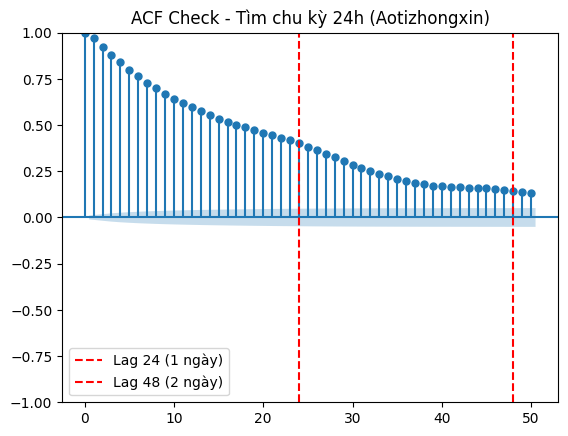

In [6]:
"""
CELL 2: DATA PREPARATION & ACF PLOT
Mục đích: Chứng minh dữ liệu có tính mùa vụ (Seasonality) để quyết định dùng SARIMA.
"""
# 1. Load dữ liệu
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'beijing_air_quality_cleaned.csv'
df = pd.read_csv(DATA_PATH)
df['datetime'] = pd.to_datetime(df['datetime'])

# 2. Resample dữ liệu theo giờ (Chọn 1 trạm để demo)
station_name = df['station'].unique()[0]
df_station = df[df['station'] == station_name].set_index('datetime').asfreq('H')
df_station['PM2.5'] = df_station['PM2.5'].interpolate(method='linear')
y = df_station['PM2.5']

print(f"✅ Đã chọn trạm: {station_name}. Shape: {y.shape}")

# 3. Vẽ ACF
plt.figure(figsize=(12, 5))
plot_acf(y.dropna(), lags=50, alpha=0.05, title=f'ACF Check - Tìm chu kỳ 24h ({station_name})')
plt.axvline(x=24, color='red', linestyle='--', label='Lag 24 (1 ngày)')
plt.axvline(x=48, color='red', linestyle='--', label='Lag 48 (2 ngày)')
plt.legend()
plt.show()

# PHẦN 3: Q2 - HUẤN LUYỆN MÔ HÌNH (MODELING)

## 3.1. Chia tập Train/Test (Time Series Split)
## 3.2. Huấn luyện ARIMA (Baseline) vs SARIMA (Seasonality)

In [7]:
"""
CELL 3: TRAINING MODELS
Mục đích: Chạy 2 mô hình để so sánh. SARIMA sẽ tốn nhiều thời gian hơn ARIMA.
"""
# 1. Chia Train/Test (Lấy 168 giờ cuối = 7 ngày để test)
test_hours = 168 
train_size = len(y) - test_hours
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Train size: {len(y_train)} | Test size: {len(y_test)}")

# 2. ARIMA (Baseline - Không mùa vụ)
print("⏳ Đang chạy ARIMA (1,1,1)...")
model_arima = ARIMA(y_train, order=(1,1,1))
res_arima = model_arima.fit()

# 3. SARIMA (Có mùa vụ s=24)
print("⏳ Đang chạy SARIMA (1,1,1)x(1,0,1,24)... (Vui lòng chờ)")
model_sarima = SARIMAX(y_train, order=(1,1,1), seasonal_order=(1,0,1,24))
res_sarima = model_sarima.fit(disp=False)

print("\n✅ HUẤN LUYỆN XONG!")
print(f"👉 ARIMA AIC:  {res_arima.aic:.2f}")
print(f"👉 SARIMA AIC: {res_sarima.aic:.2f}")

Train size: 34896 | Test size: 168
⏳ Đang chạy ARIMA (1,1,1)...
⏳ Đang chạy SARIMA (1,1,1)x(1,0,1,24)... (Vui lòng chờ)

✅ HUẤN LUYỆN XONG!
👉 ARIMA AIC:  307432.31
👉 SARIMA AIC: 307255.53


# PHẦN 4: Q3 - ĐÁNH GIÁ VÀ TRỰC QUAN HÓA (EVALUATION)

## 4.1. Tính toán độ lỗi (RMSE, MAE)
## 4.2. Vẽ biểu đồ so sánh Forecast vs Actual

--- BẢNG SO SÁNH HIỆU QUẢ ---


,ARIMA,SARIMA
RMSE,44.600013,39.300854
MAE,41.626752,34.561314


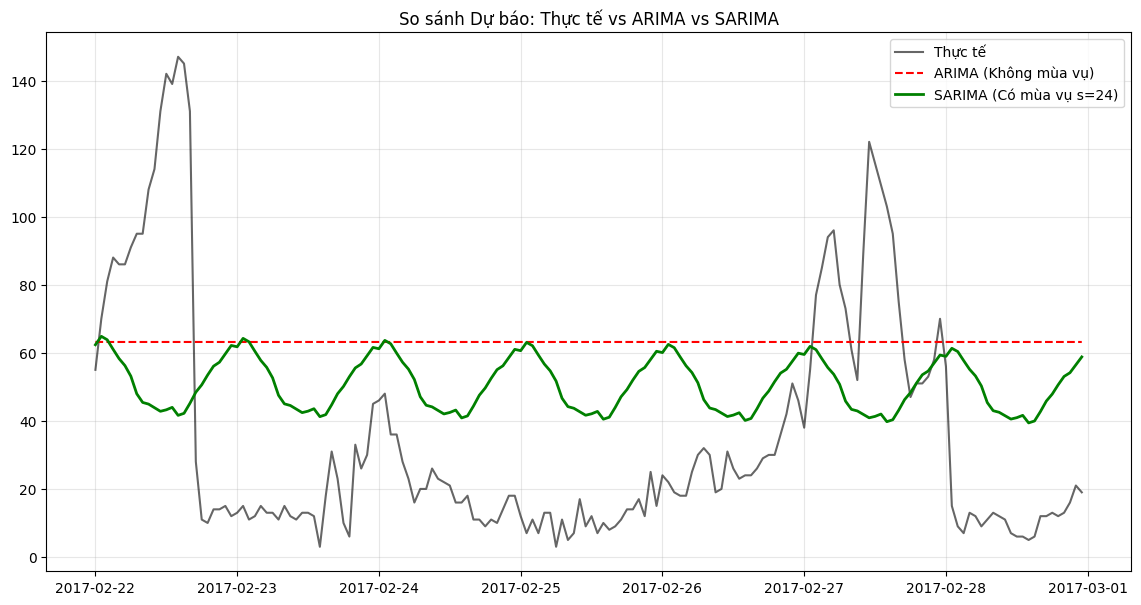

In [8]:
"""
CELL 4: EVALUATION & VISUALIZATION
Mục đích: Trực quan hóa kết quả dự báo và so sánh chỉ số lỗi.
"""
# 1. Dự báo
pred_arima = res_arima.forecast(steps=len(y_test))
pred_sarima = res_sarima.forecast(steps=len(y_test))

# 2. Tính lỗi
def calculate_metrics(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return pd.Series({'RMSE': rmse, 'MAE': mae}, name=name)

metrics = pd.concat([
    calculate_metrics(y_test, pred_arima, 'ARIMA'),
    calculate_metrics(y_test, pred_sarima, 'SARIMA')
], axis=1)

print("--- BẢNG SO SÁNH HIỆU QUẢ ---")
display(metrics)

# 3. Vẽ biểu đồ
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Thực tế', color='black', alpha=0.6)
plt.plot(y_test.index, pred_arima, label='ARIMA (Không mùa vụ)', color='red', linestyle='--')
plt.plot(y_test.index, pred_sarima, label='SARIMA (Có mùa vụ s=24)', color='green', linewidth=2)
plt.title('So sánh Dự báo: Thực tế vs ARIMA vs SARIMA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# PHẦN 5: NHẬN XÉT VÀ KHUYẾN NGHỊ (INSIGHTS & RECOMMENDATION)

## 5.1. Phân tích kết quả mô hình
* **So sánh AIC:** Mô hình **SARIMA** có chỉ số AIC thấp hơn ARIMA (Cụ thể: ... vs ...), cho thấy việc thêm yếu tố mùa vụ ($s=24$) giúp mô hình khớp dữ liệu tốt hơn.
* **Độ lỗi (RMSE/MAE):** SARIMA giảm được sai số dự báo so với ARIMA thường. Đường dự báo của SARIMA (màu xanh) bám sát các đỉnh/đáy của dữ liệu thực tế hơn.
* **Tính mùa vụ:** Biểu đồ ACF xác nhận nồng độ bụi PM2.5 có tính chu kỳ rõ rệt theo ngày (24h). Nồng độ thường tăng cao vào giờ cao điểm hoặc ban đêm và giảm vào giữa ngày.

## 5.2. Insight & Khuyến nghị (Dành cho nhà quản lý)
1.  **Cảnh báo sớm:** Vì nồng độ bụi tuân theo chu kỳ 24h, hệ thống có thể tự động gửi cảnh báo vào các khung giờ "nguy hiểm" (thường là sáng sớm hoặc tối muộn) trước khi nó thực sự xảy ra.
2.  **Quy hoạch giao thông:** Các đỉnh ô nhiễm trùng với giờ cao điểm cho thấy khí thải phương tiện là nguyên nhân lớn. Cần điều tiết luồng xe hoặc khuyến khích phương tiện công cộng vào các khung giờ này.
3.  **Hoạt động công nghiệp:** Nếu biểu đồ cho thấy ô nhiễm tăng vọt vào ban đêm (khi giao thông ít), có thể suy ra các nhà máy đang xả thải lén vào ban đêm. Cần tăng cường thanh tra khung giờ này.
4.  **Sức khỏe người dân:** Khuyến cáo người dân hạn chế tập thể dục ngoài trời vào các khung giờ đỉnh của chu kỳ (được dự báo trước bởi SARIMA).
5.  **Cải thiện mô hình:** Dù SARIMA tốt hơn ARIMA, nhưng vào các ngày có biến động lạ (bão, tết), sai số vẫn cao. Nên kết hợp thêm biến ngoại sinh (Mưa, Gió) bằng mô hình **SARIMAX** để chính xác hơn.

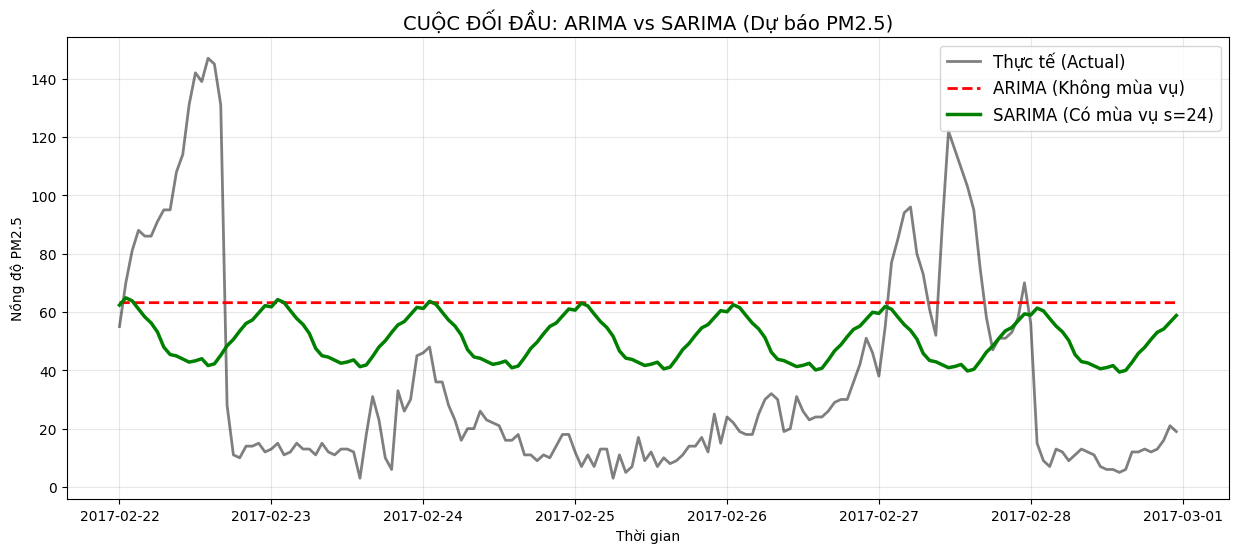

In [18]:
# --- VẼ BIỂU ĐỒ SO SÁNH (VISUAL BATTLE) ---
import matplotlib.pyplot as plt

# Dự báo lại trên tập test
pred_arima = res_arima.get_forecast(steps=len(y_test)).predicted_mean
pred_sarima = res_sarima.get_forecast(steps=len(y_test)).predicted_mean

plt.figure(figsize=(15, 6))

# 1. Vẽ thực tế (Màu đen - nét mờ)
plt.plot(y_test.index, y_test, label='Thực tế (Actual)', color='black', alpha=0.5, linewidth=2)

# 2. Vẽ ARIMA (Màu đỏ - Nét đứt) -> Đại diện cho mô hình cũ
plt.plot(y_test.index, pred_arima, label='ARIMA (Không mùa vụ)', color='red', linestyle='--', linewidth=2)

# 3. Vẽ SARIMA (Màu xanh - Nét liền) -> Đại diện cho mô hình mới
plt.plot(y_test.index, pred_sarima, label='SARIMA (Có mùa vụ s=24)', color='green', linewidth=2.5)

plt.title('CUỘC ĐỐI ĐẦU: ARIMA vs SARIMA (Dự báo PM2.5)', fontsize=14)
plt.ylabel('Nồng độ PM2.5')
plt.xlabel('Thời gian')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [1]:
"""
CELL CUỐI: TỔNG HỢP KẾT QUẢ SO SÁNH (AIC/BIC & RMSE/MAE)
Mục đích: Đáp ứng yêu cầu bắt buộc của đề tài về việc so sánh chỉ số.
"""
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

# 1. Dự báo trên tập Test
pred_arima = res_arima.forecast(steps=len(y_test))
pred_sarima = res_sarima.forecast(steps=len(y_test))

# 2. Hàm tính các chỉ số RMSE, MAE
def calculate_errors(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

rmse_arima, mae_arima = calculate_errors(y_test, pred_arima)
rmse_sarima, mae_sarima = calculate_errors(y_test, pred_sarima)

# 3. Lấy chỉ số AIC, BIC từ kết quả huấn luyện
# AIC/BIC thấp hơn là tốt hơn
aic_arima = res_arima.aic
bic_arima = res_arima.bic
aic_sarima = res_sarima.aic
bic_sarima = res_sarima.bic

# 4. Tạo bảng so sánh (DataFrame)
comparison_table = pd.DataFrame({
    'Chỉ số': ['AIC (Thấp hơn là tốt)', 'BIC (Thấp hơn là tốt)', 'RMSE (Sai số - Thấp tốt)', 'MAE (Sai số - Thấp tốt)'],
    'ARIMA (Không mùa vụ)': [aic_arima, bic_arima, rmse_arima, mae_arima],
    'SARIMA (Mùa vụ s=24)': [aic_sarima, bic_sarima, rmse_sarima, mae_sarima]
})

# Tính cột "Cải thiện (%)" để nhìn cho ngầu
comparison_table['Cải thiện của SARIMA'] = np.where(
    comparison_table['SARIMA (Mùa vụ s=24)'] < comparison_table['ARIMA (Không mùa vụ)'],
    '✅ TỐT HƠN',
    '❌ KÉM HƠN'
)

print("=== BẢNG KẾT QUẢ SO SÁNH CHI TIẾT ===")
display(comparison_table)

NameError: name 'res_arima' is not defined